In [1]:
from src.features import moment_like_features, prepare_targets
from src.hcr import fit_lasso, plot_example_densities
from src.evaluation import mean_log_likelihood, mse_evaluation

def eval(X_train_norm, X_test_norm, 
         y_train_norm, y_test_norm,
         y_test, y_denorm,
         N_feature, N_target, 
         method="softplus", 
         a=1, b=1, eps=1e-6):
    
    print(f"----- Target deg. {N_target}, feature deg. {N_feature} -----")

    V_train = moment_like_features(X_train_norm, N_feature)
    V_test  = moment_like_features(X_test_norm, N_feature)
    targets_train = prepare_targets(y_train_norm, N_target)

    models = []
    for n in range(N_target):
        models.append(fit_lasso(V_train, targets_train[n]))

    plot_example_densities(V_test, y_test_norm, 
                           models, method="softplus", a=a, b=b, eps=eps,
                           name=f"Example densities (deg. {N_target}, feature deg. {N_feature})",
                           seed=33, raw=True)

    ll = mean_log_likelihood(V_test, y_test_norm, models,
                             method=method, a=a, b=b, eps=eps)
    print(f"HL mean log-likelihood: {ll:.4f}")

    mse = mse_evaluation(V_test, y_test, models, y_denorm,
                         method=method, a=a, b=b, eps=eps)
    print(f"HL test MSE: {mse:.4f}")

In [2]:
from src.cv import cross_validate

def cv_eval(X, y, N_feature, N_target, 
            method="softplus", a=1, b=1, eps=1e-6):
    print(f"----- Target deg. {N_target}, feature deg. {N_feature} -----")
    
    ll, mse, coeffs_list = cross_validate(X, y, 
                             N_feature=N_feature, N_target=N_target,
                             method=method, a=a, b=b, eps=eps,
                             return_coeffs=True)
    return ll, mse, coeffs_list

### Dataset: Energy Efficiency with HL (heating load) as target

In [3]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Heating Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Train test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

### EDF normalization

In [5]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Heating Load", edf_models)

### Evaluation: all independet variables available 

In [6]:
results = {}

----- Target deg. 7, feature deg. 7 -----


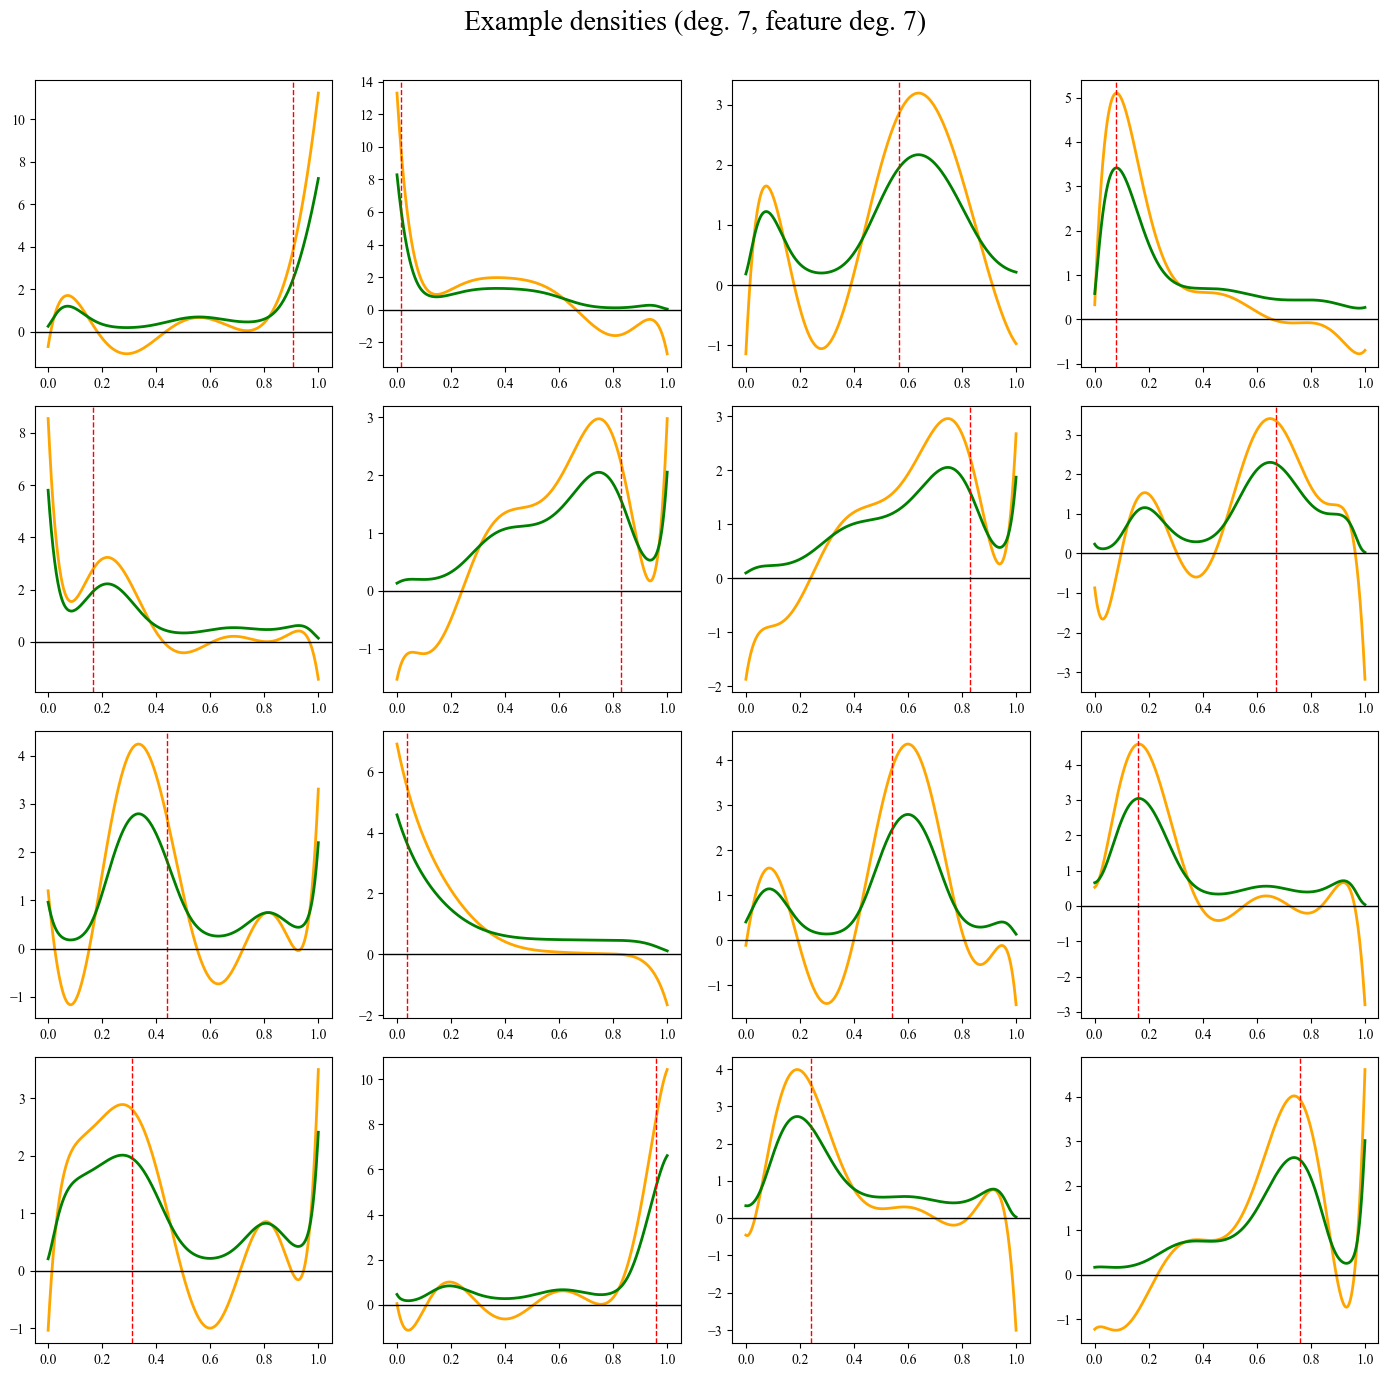

HL mean log-likelihood: 0.9076
HL test MSE: 23.3377


In [7]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="softplus")
results["softplus"] = (ll, mse, coeffs_list)

In [9]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.83 0.88 0.93 0.82 0.89 0.91 0.81 0.82 0.82 0.8 ]
  mean LL : 0.8512
  std LL  : 0.0431

Mean square error:
  per fold: [18.   18.06 17.14 22.4  27.93 15.88 16.98 24.37 17.86 17.04]
  mean MSE: 19.5654
  std MSE : 3.7593


----- Target deg. 7, feature deg. 7 -----


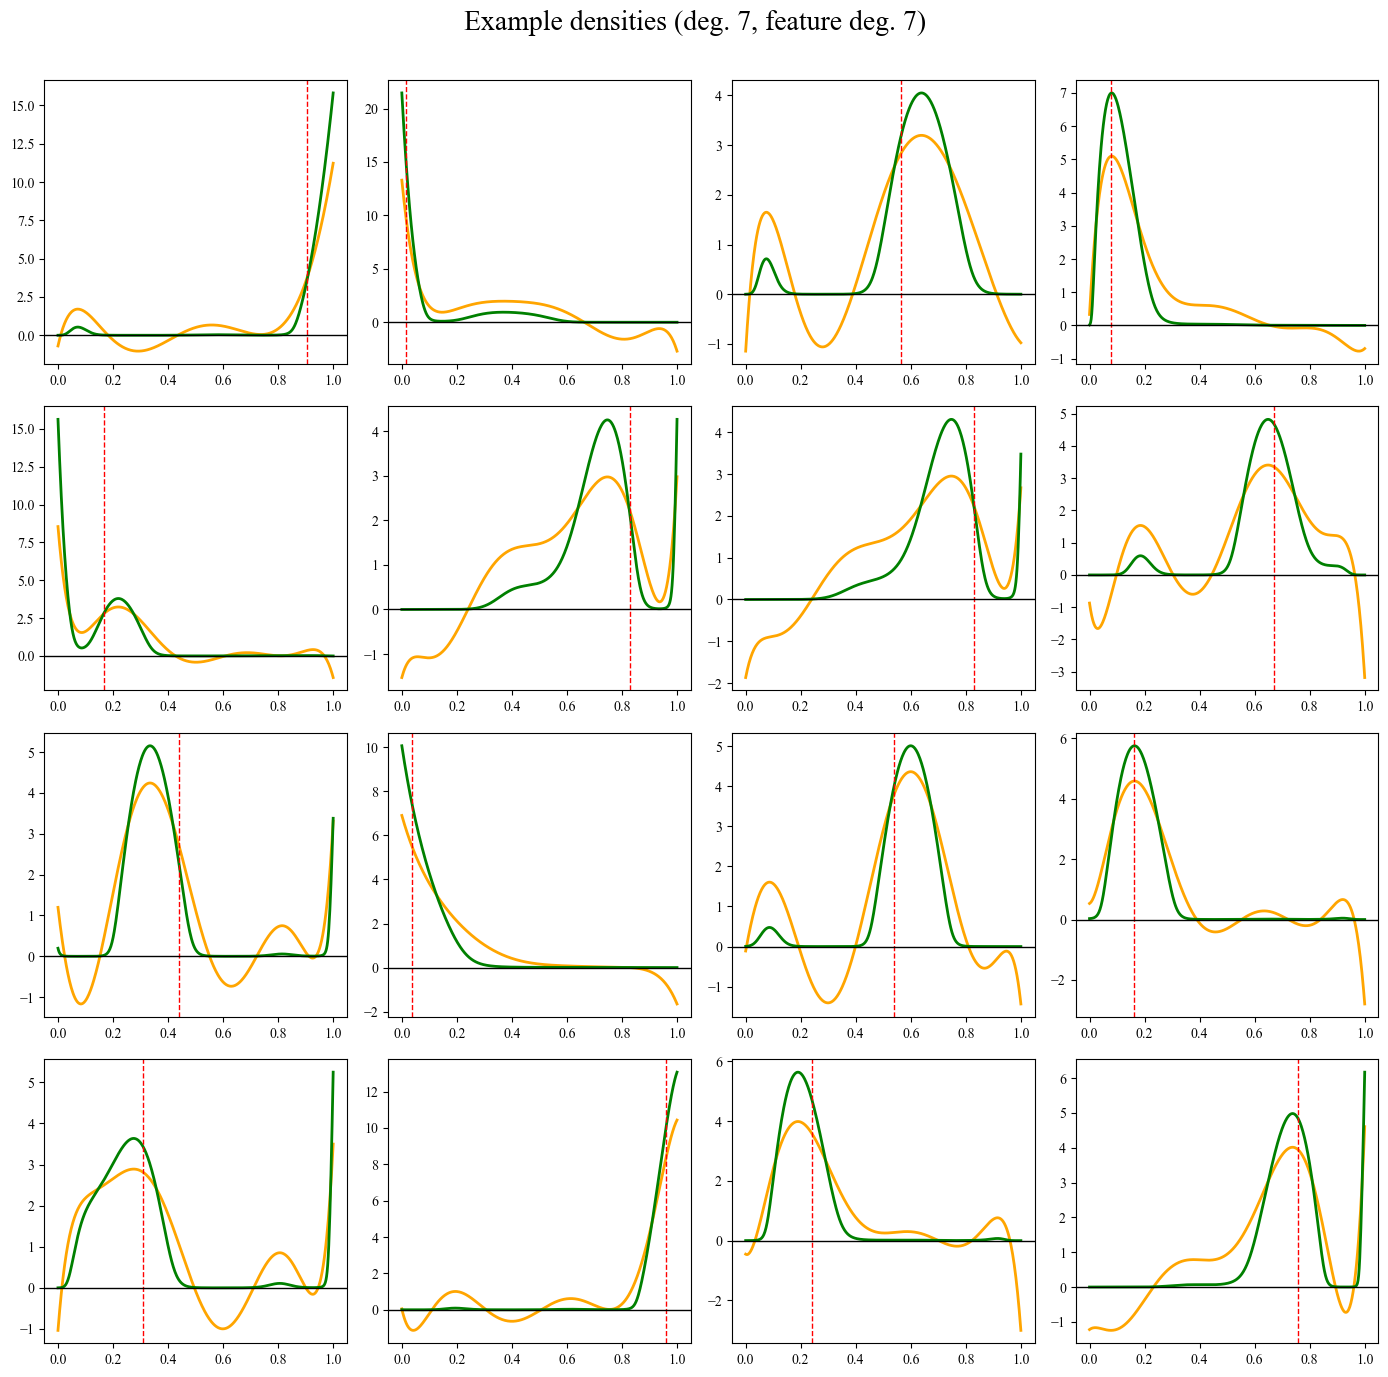

HL mean log-likelihood: 1.3821
HL test MSE: 3.4389


In [10]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results["param-softplus"] = (ll, mse, coeffs_list)

In [12]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.13 1.29 1.48 1.1  1.26 1.34 1.06 1.2  1.08 1.17]
  mean LL : 1.2098
  std LL  : 0.1252

Mean square error:
  per fold: [3.55 2.71 2.15 3.3  5.45 3.01 4.56 4.1  5.12 2.46]
  mean MSE: 3.6410
  std MSE : 1.0719


----- Target deg. 7, feature deg. 7 -----


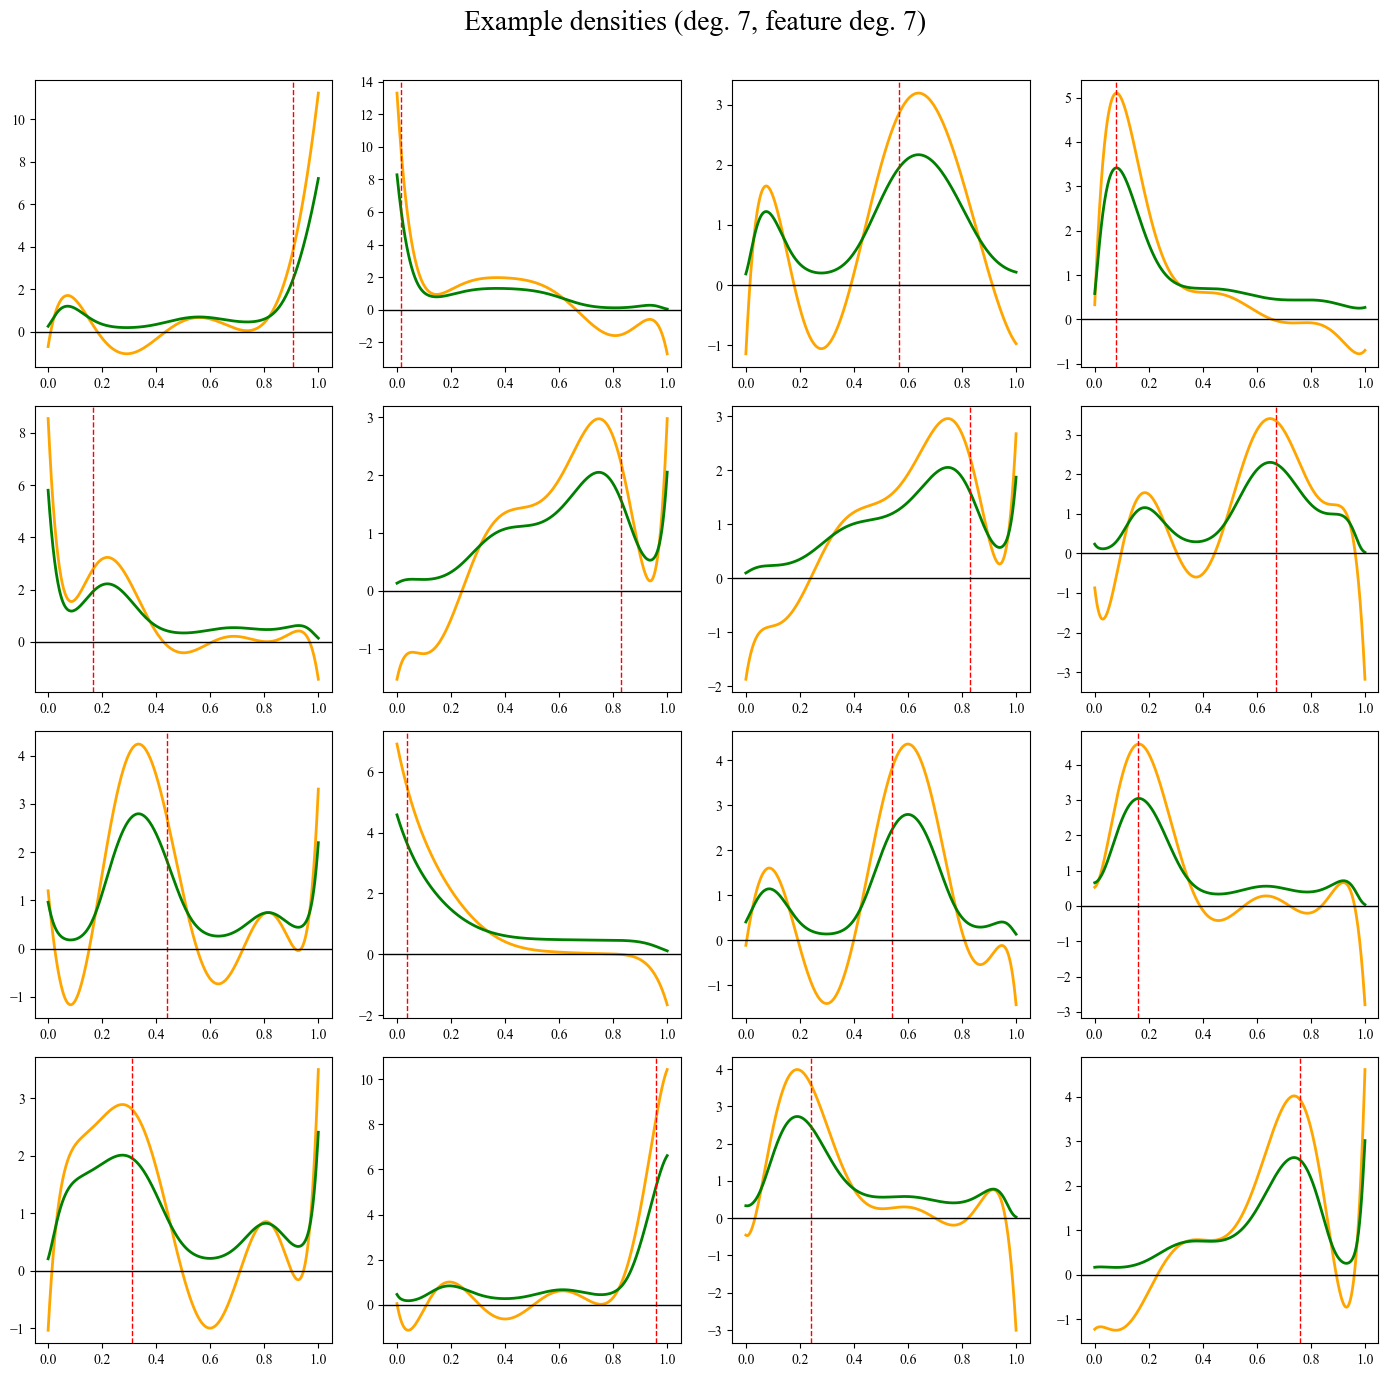

HL mean log-likelihood: 1.1425
HL test MSE: 11.6265


In [13]:
eval(X_train_norm, X_test_norm,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7, 
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X, y, N_feature=7, N_target=7, 
                               method="clip")
results["clip"] = (ll, mse, coeffs_list)

In [15]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.04 1.07 1.17 1.02 0.96 1.13 1.01 1.04 1.03 0.87]
  mean LL : 1.0338
  std LL  : 0.0795

Mean square error:
  per fold: [ 9.09  8.55  7.86 10.76 15.46  7.78  7.98 12.7   8.94  8.17]
  mean MSE: 9.7298
  std MSE : 2.4065


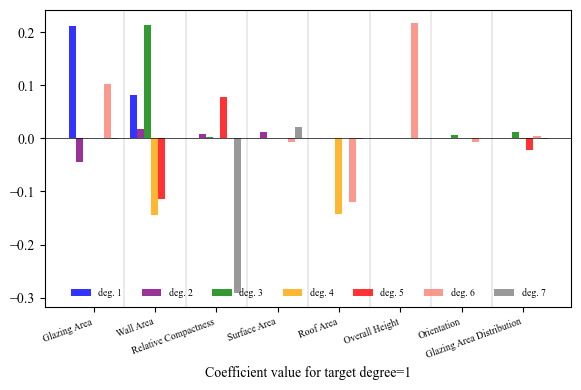

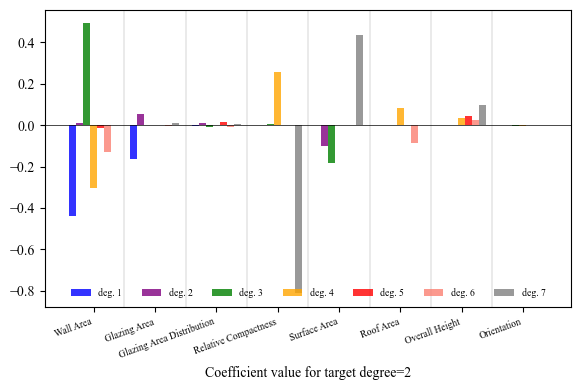

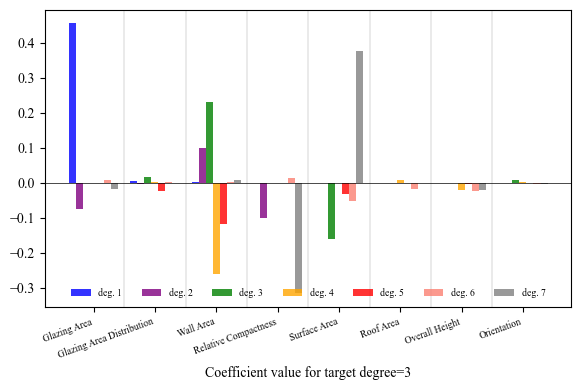

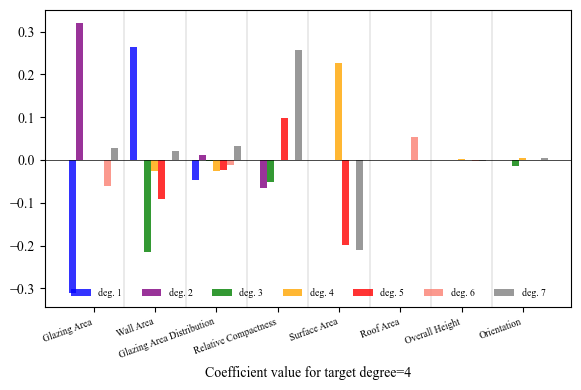

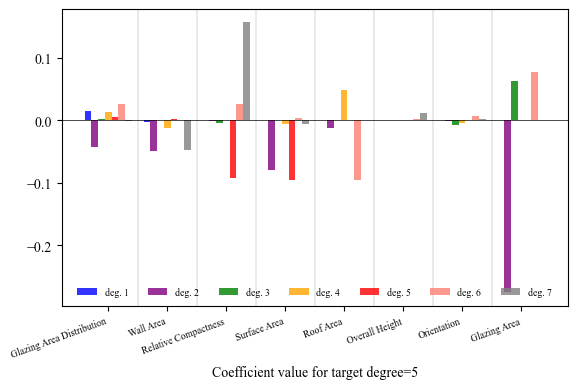

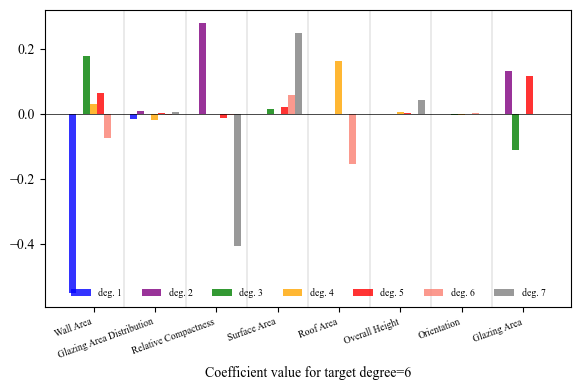

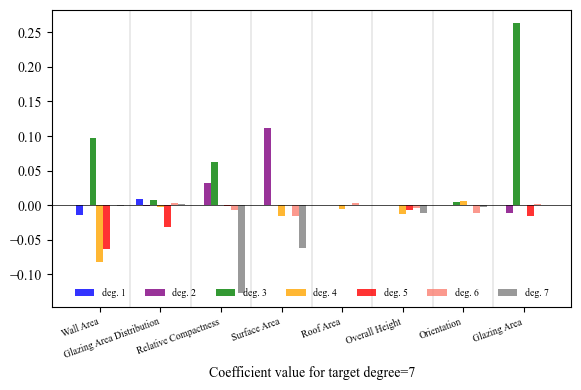

In [65]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)

### Evaluation: model based on four independet variables

In [16]:
four_columns = ["Surface Area", "Roof Area", "Relative Compactness", "Glazing Area"]
X_four = X[four_columns]
X_train_four = X_train_norm[four_columns]
X_test_four = X_test_norm[four_columns]
results_four = {}

----- Target deg. 7, feature deg. 7 -----


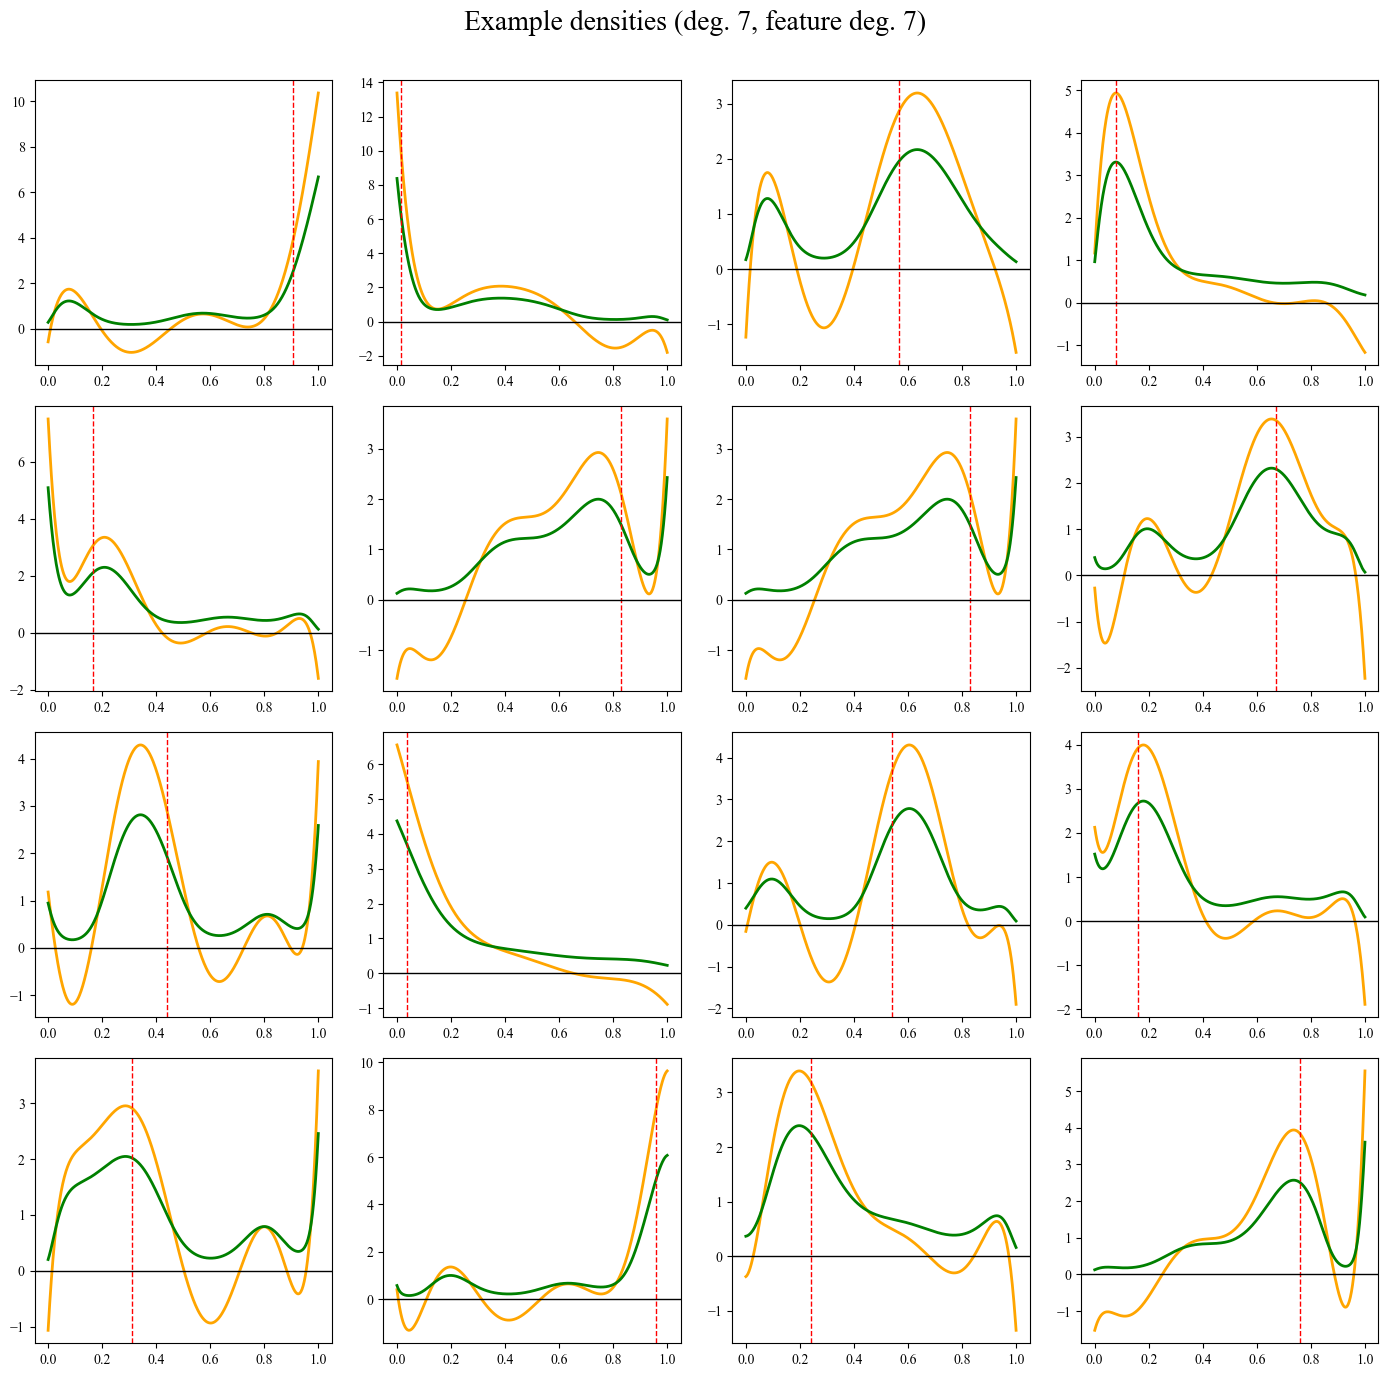

HL mean log-likelihood: 0.9136
HL test MSE: 23.0987


In [17]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="softplus")
results_four["softplus"] = (ll, mse, coeffs_list)

In [19]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.83 0.88 0.92 0.82 0.9  0.9  0.82 0.83 0.82 0.8 ]
  mean LL : 0.8536
  std LL  : 0.0408

Mean square error:
  per fold: [18.1  18.19 17.18 22.32 27.52 16.15 17.18 24.7  17.84 17.27]
  mean MSE: 19.6449
  std MSE : 3.6401


----- Target deg. 7, feature deg. 7 -----


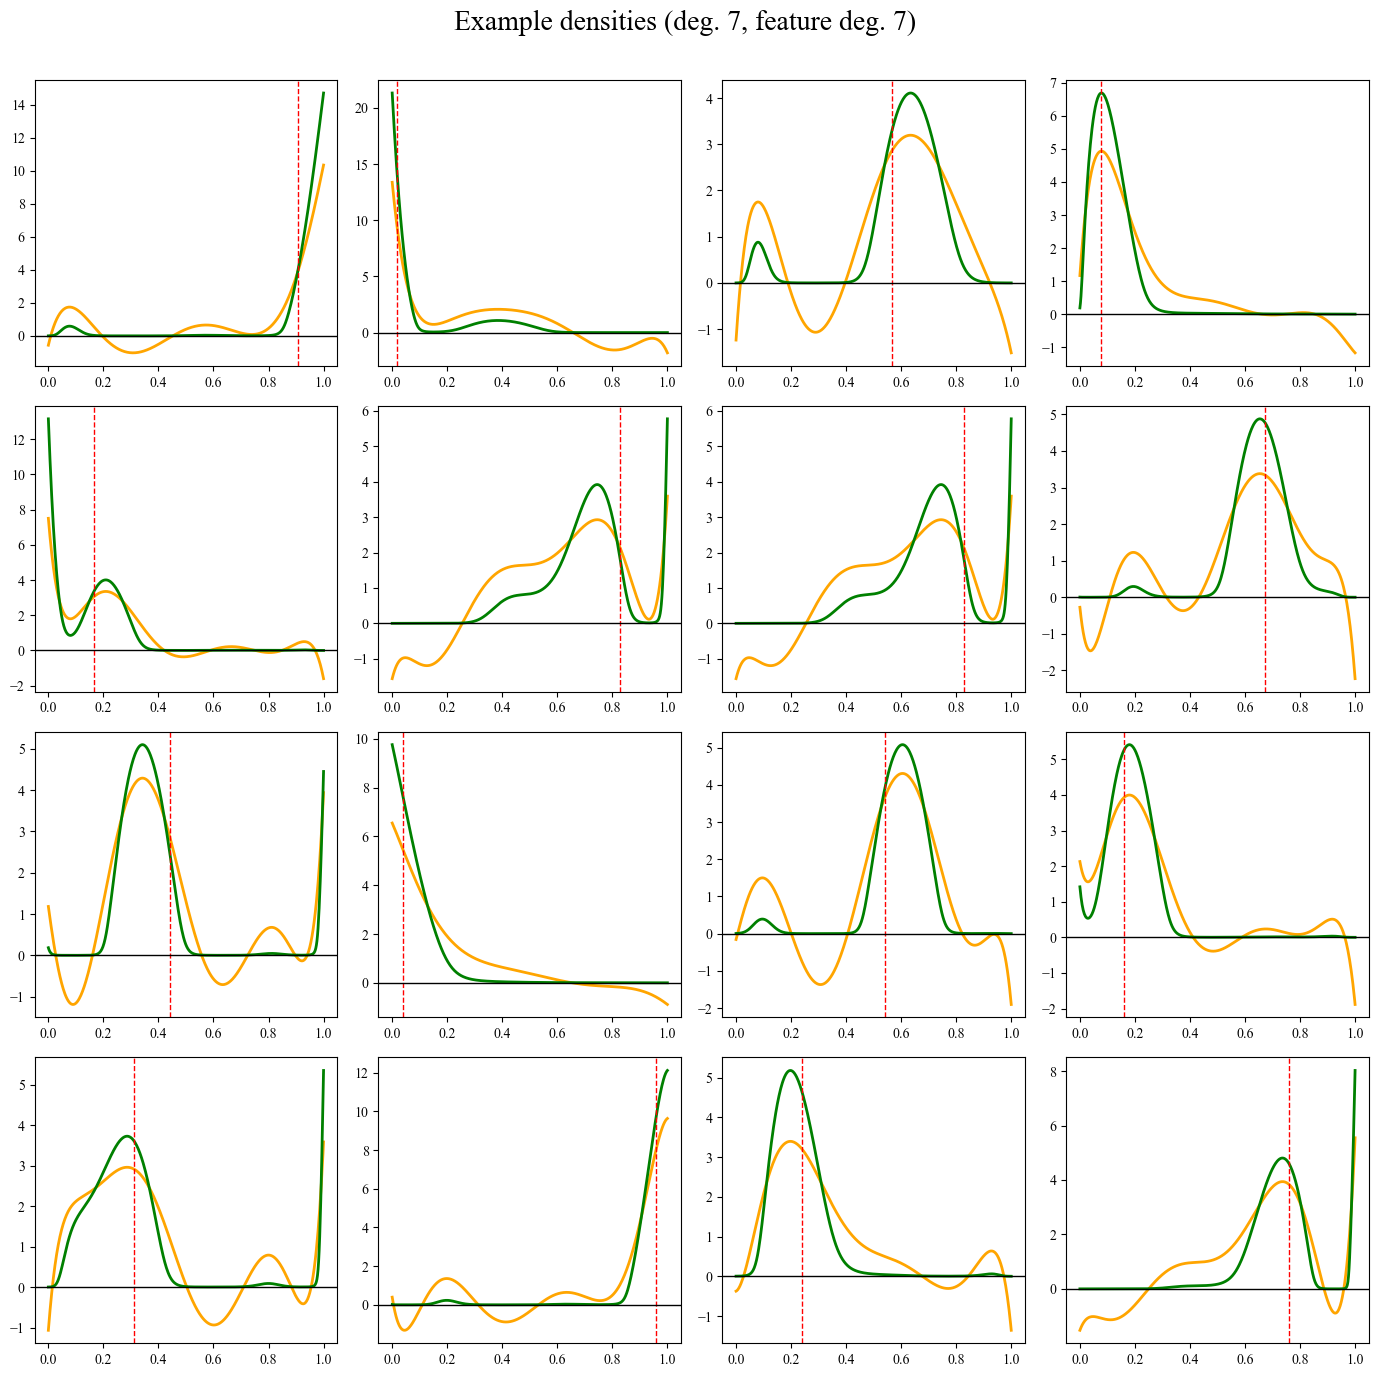

HL mean log-likelihood: 1.4082
HL test MSE: 3.1543


In [20]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results_four["param-softplus"] = (ll, mse, coeffs_list)

In [22]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.13 1.32 1.48 1.12 1.27 1.34 1.08 1.23 1.09 1.18]
  mean LL : 1.2239
  std LL  : 0.1216

Mean square error:
  per fold: [3.29 2.59 2.22 2.71 5.28 3.24 4.52 3.75 5.11 2.57]
  mean MSE: 3.5283
  std MSE : 1.0446


----- Target deg. 7, feature deg. 7 -----


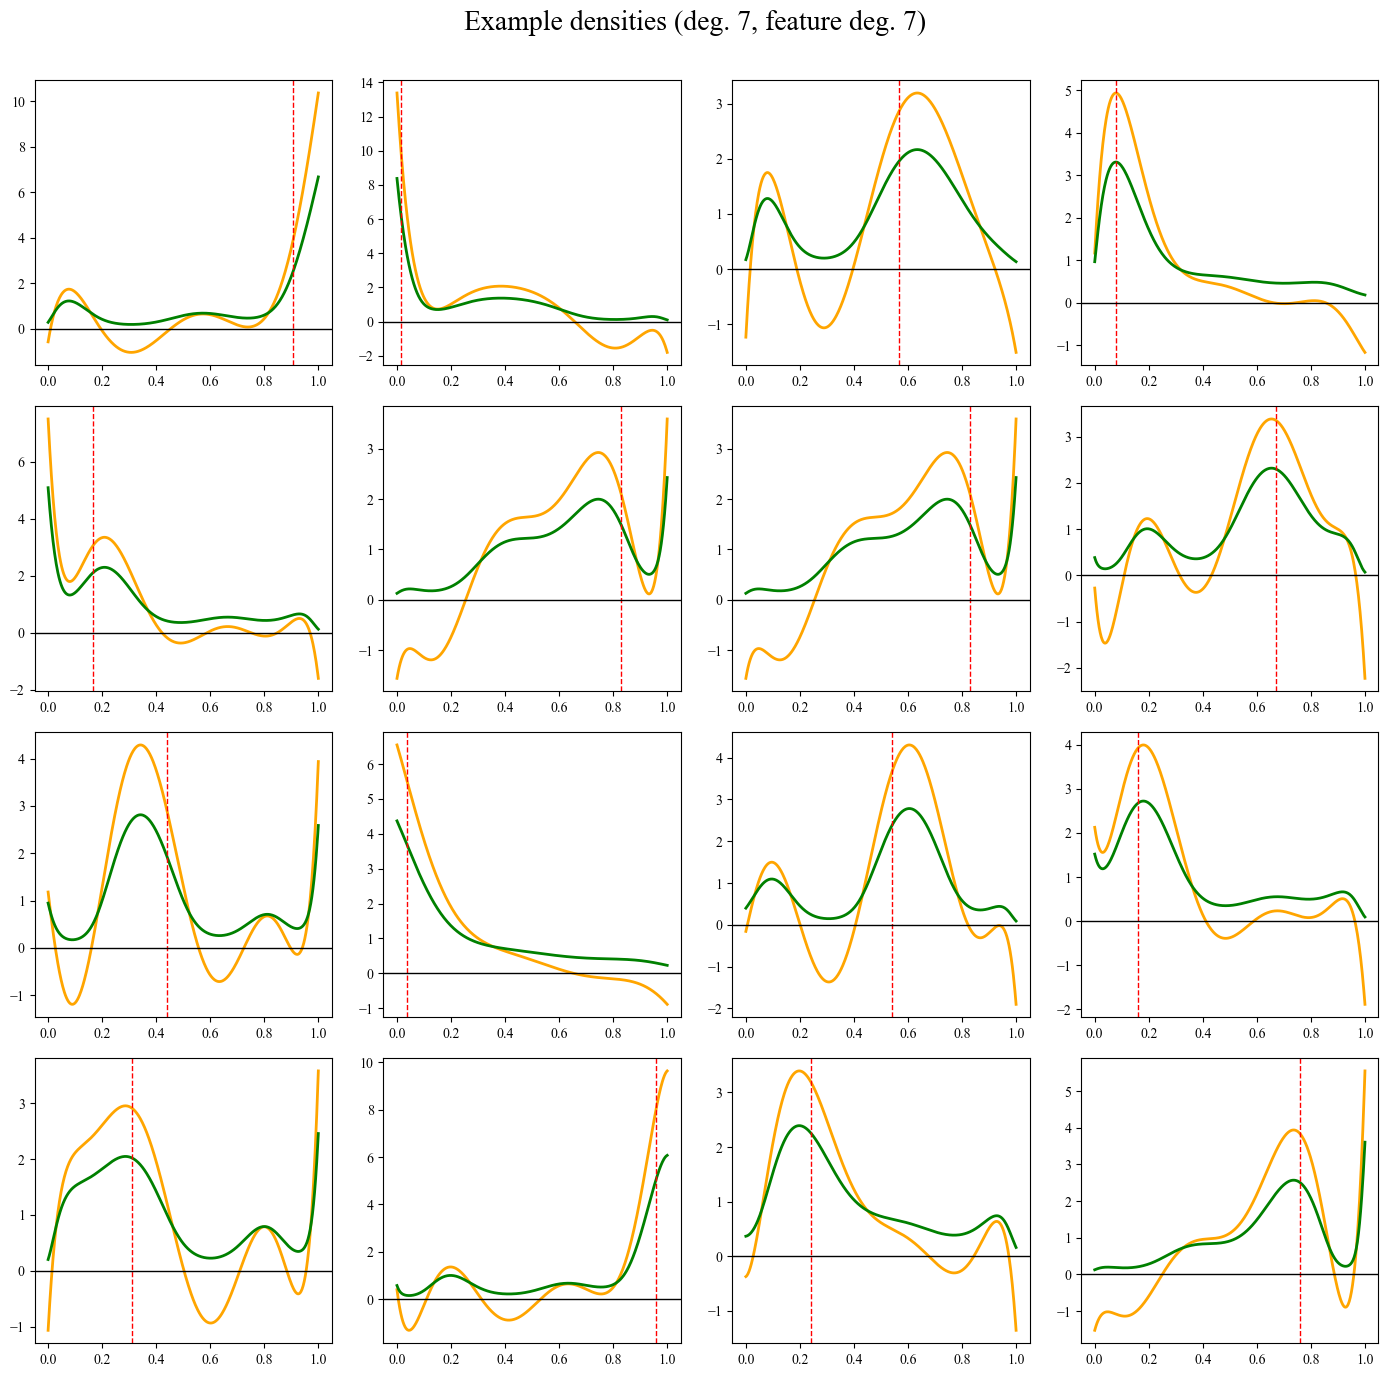

HL mean log-likelihood: 1.1515
HL test MSE: 10.9872


In [23]:
eval(X_train_four, X_test_four,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_four, y, N_feature=7, N_target=7, 
                               method="clip")
results_four["clip"] = (ll, mse, coeffs_list)

In [25]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.04 1.09 1.16 1.03 0.96 1.13 1.02 1.05 1.03 0.87]
  mean LL : 1.0381
  std LL  : 0.0785

Mean square error:
  per fold: [ 8.26  8.25  7.85 10.29 14.51  7.92  7.78 12.58  8.43  8.19]
  mean MSE: 9.4072
  std MSE : 2.2200


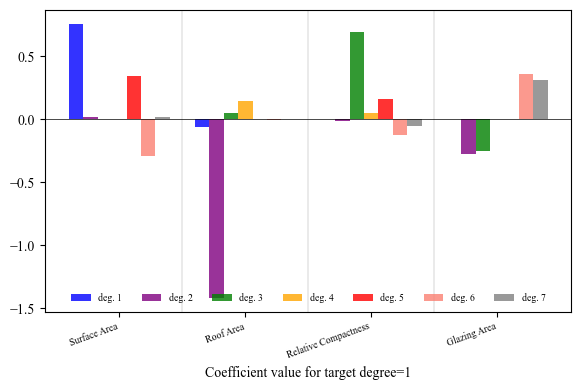

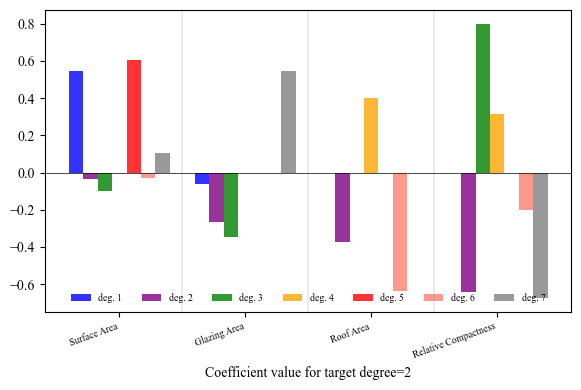

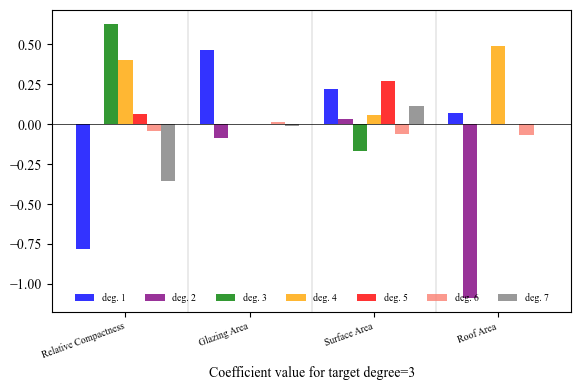

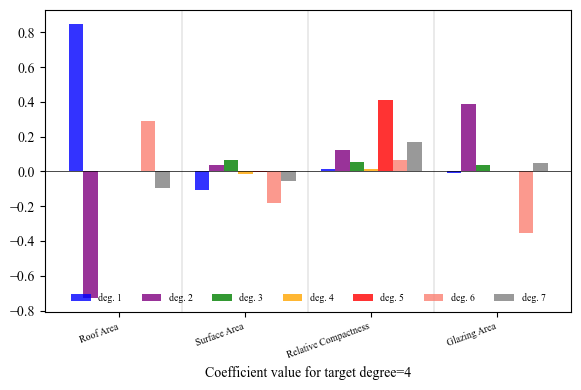

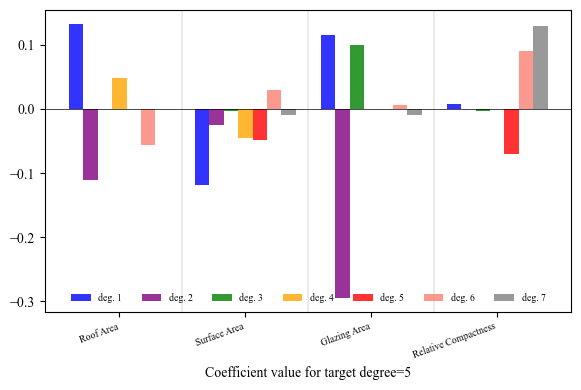

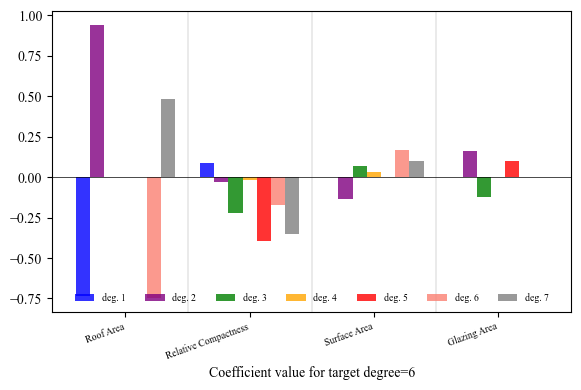

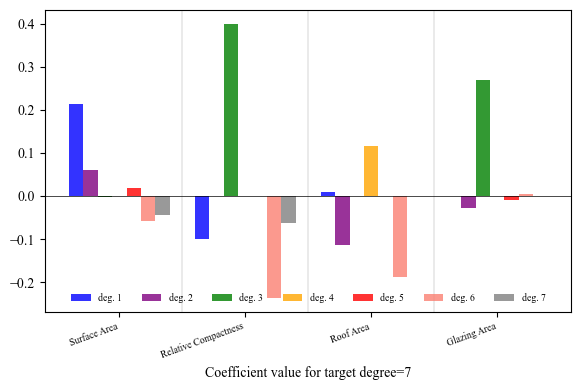

In [66]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results_four["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)

### Evaluation: model based on six independet variables

In [26]:
six_columns = ["Surface Area", "Roof Area", "Relative Compactness", "Glazing Area", "Wall Area", "Overall Height"]
X_six = X[six_columns]
X_train_six = X_train_norm[six_columns]
X_test_six = X_test_norm[six_columns]
results_six = {}

----- Target deg. 7, feature deg. 7 -----


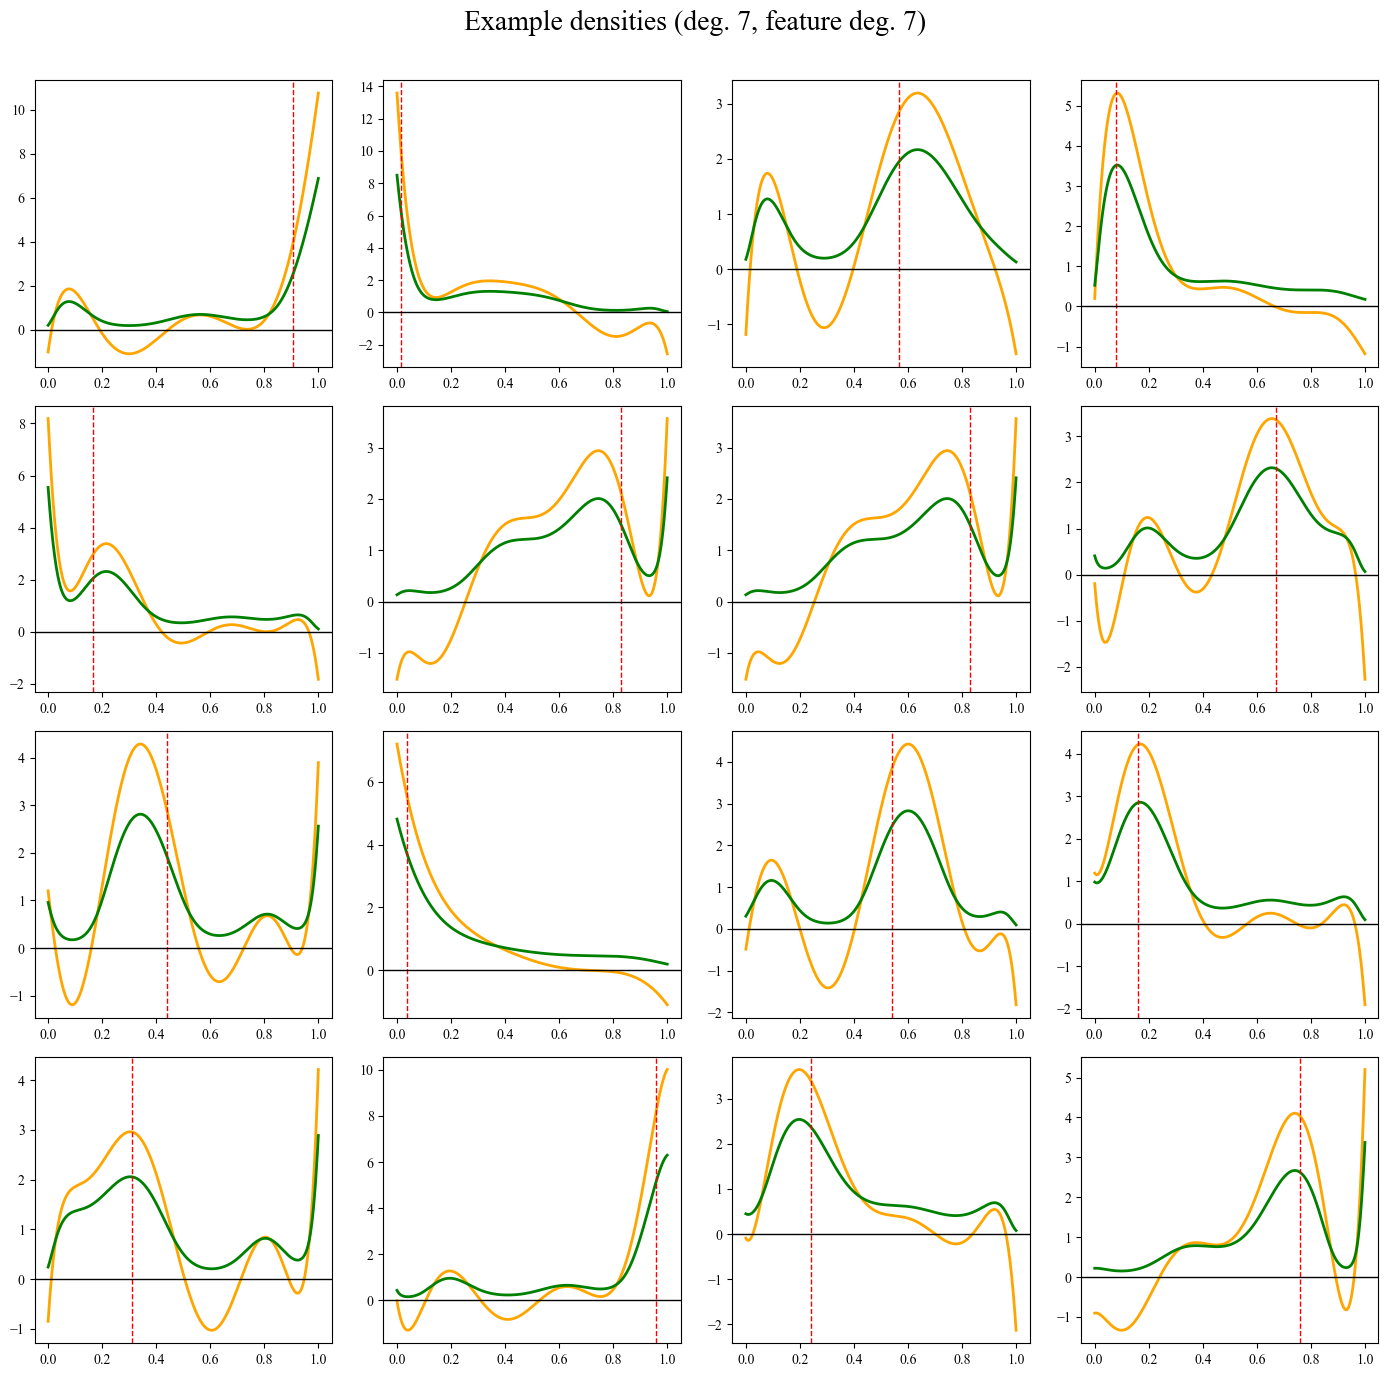

HL mean log-likelihood: 0.9187
HL test MSE: 23.3261


In [27]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="softplus")
results_six["softplus"] = (ll, mse, coeffs_list)

In [29]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [0.84 0.89 0.93 0.82 0.9  0.91 0.82 0.83 0.82 0.81]
  mean LL : 0.8575
  std LL  : 0.0431

Mean square error:
  per fold: [18.02 17.88 17.02 22.49 27.8  15.94 16.8  24.48 17.54 16.95]
  mean MSE: 19.4936
  std MSE : 3.7936


----- Target deg. 7, feature deg. 7 -----


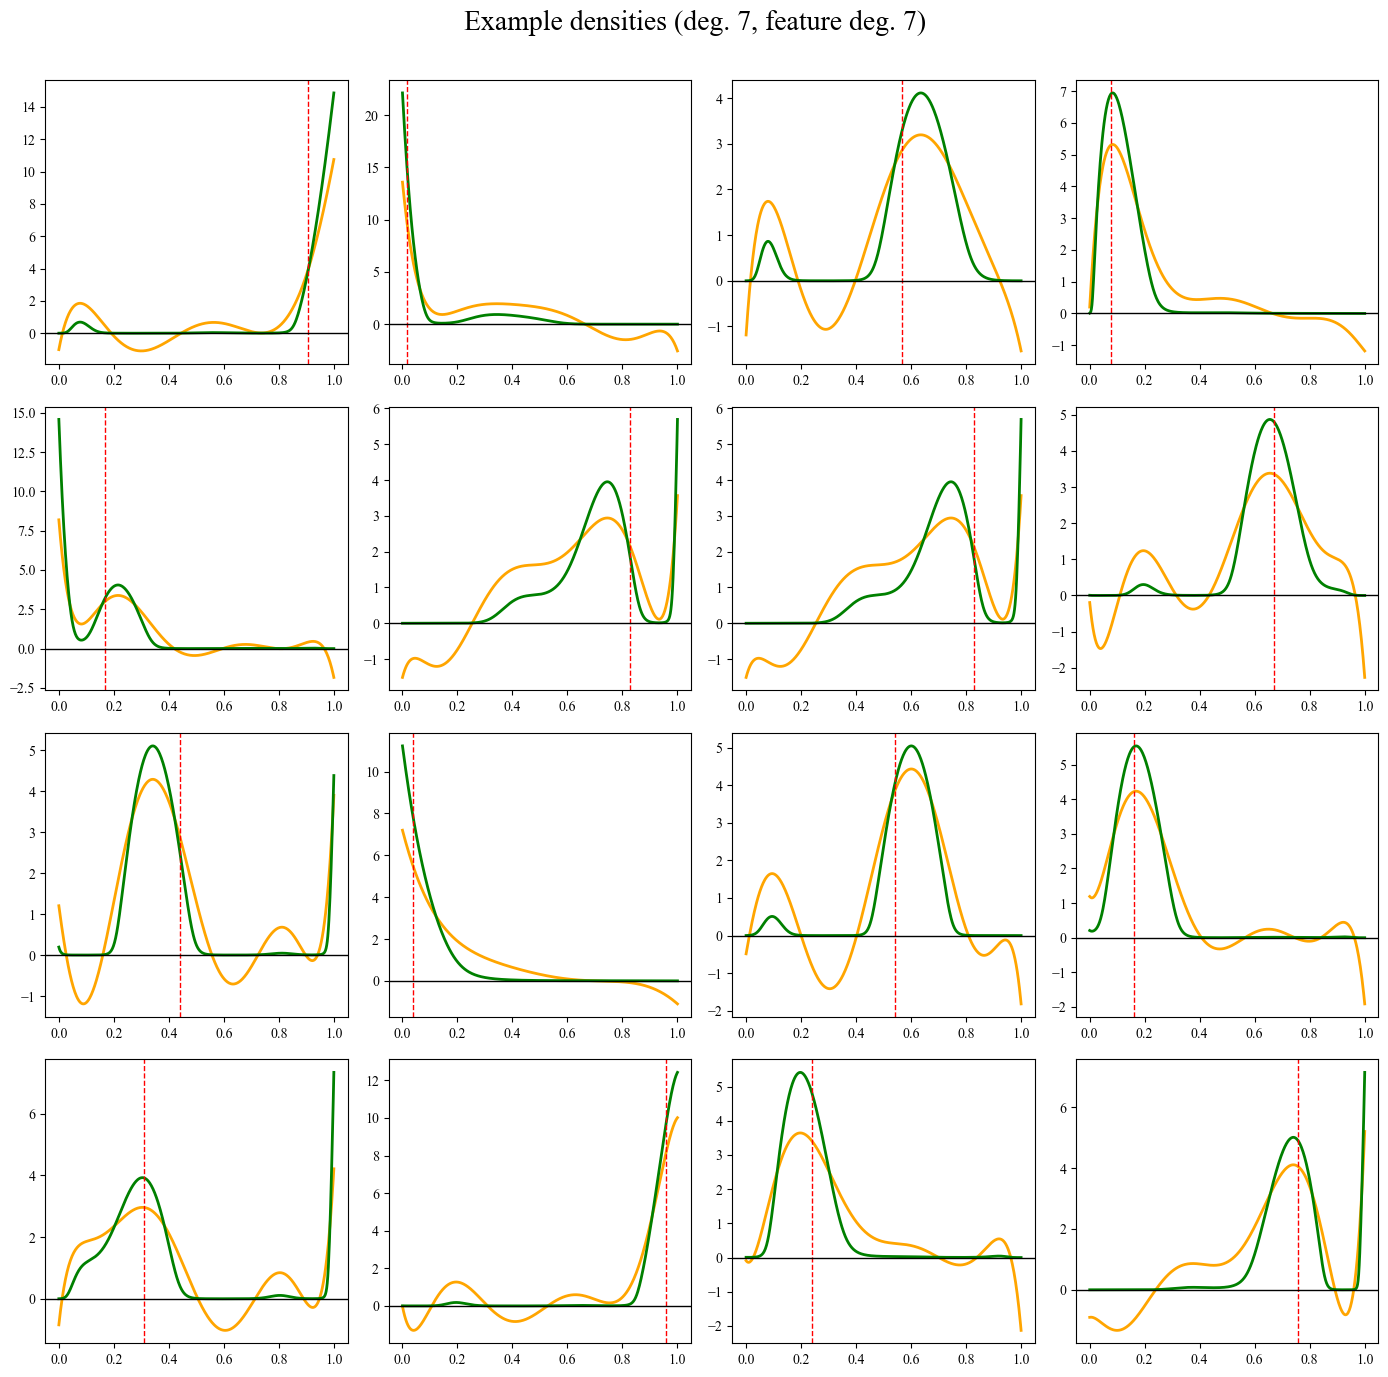

HL mean log-likelihood: 1.4055
HL test MSE: 3.2278


In [30]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="softplus", a=3., b=100.)

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="softplus", a=3., b=100.)
results_six["param-softplus"] = (ll, mse, coeffs_list)

In [32]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.16 1.32 1.48 1.12 1.27 1.34 1.06 1.22 1.08 1.18]
  mean LL : 1.2235
  std LL  : 0.1249

Mean square error:
  per fold: [3.31 2.65 2.14 3.   5.15 3.07 4.55 3.75 5.26 2.43]
  mean MSE: 3.5296
  std MSE : 1.0555


----- Target deg. 7, feature deg. 7 -----


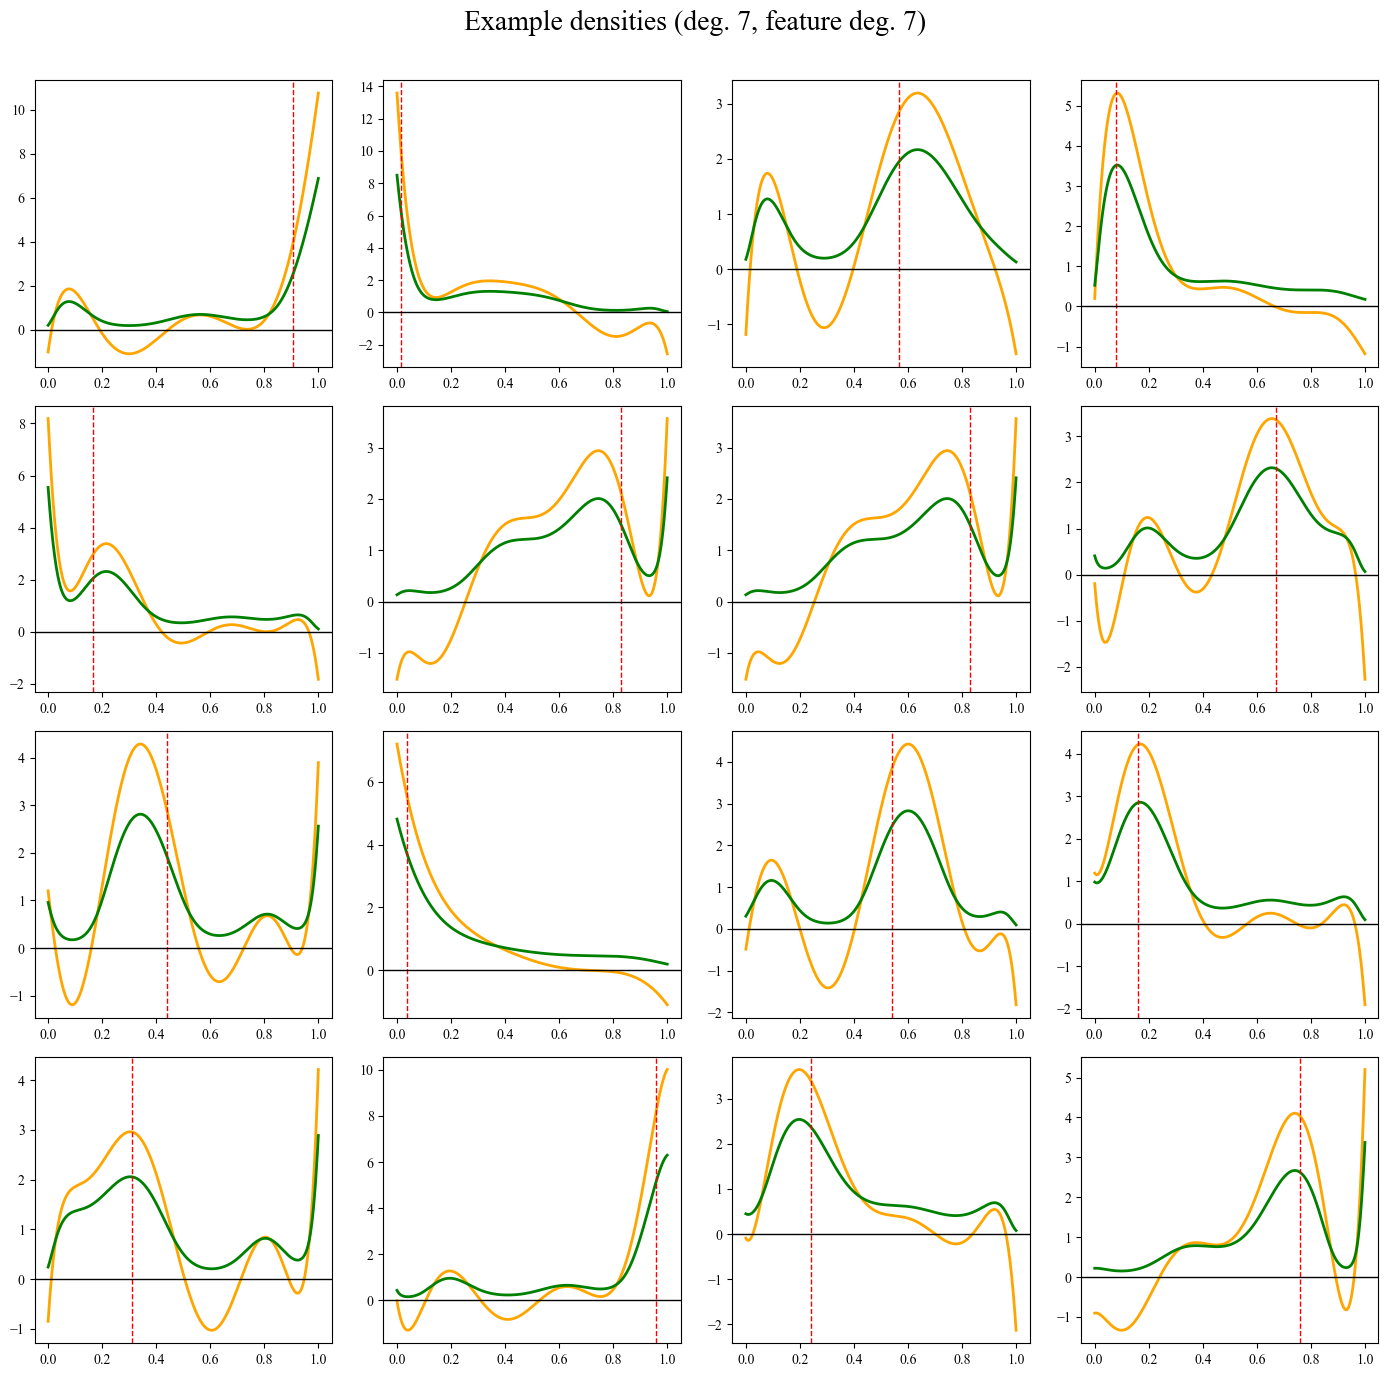

HL mean log-likelihood: 1.1553
HL test MSE: 11.1695


In [36]:
eval(X_train_six, X_test_six,
     y_train_norm, y_test_norm,
     y_test, y_denorm,
     N_feature=7, N_target=7,
     method="clip")

In [ ]:
ll, mse, coeffs_list = cv_eval(X_six, y, N_feature=7, N_target=7, 
                               method="clip")
results_six["clip"] = (ll, mse, coeffs_list)

In [35]:
from src.cv import print_cv_results
print_cv_results(ll, mse)


Log-likelihood:
  per fold: [1.06 1.08 1.17 1.03 0.97 1.14 1.01 1.05 1.03 0.87]
  mean LL : 1.0414
  std LL  : 0.0792

Mean square error:
  per fold: [ 8.13  8.2   7.74 10.5  14.68  7.68  7.6  12.26  8.68  8.01]
  mean MSE: 9.3480
  std MSE : 2.2745


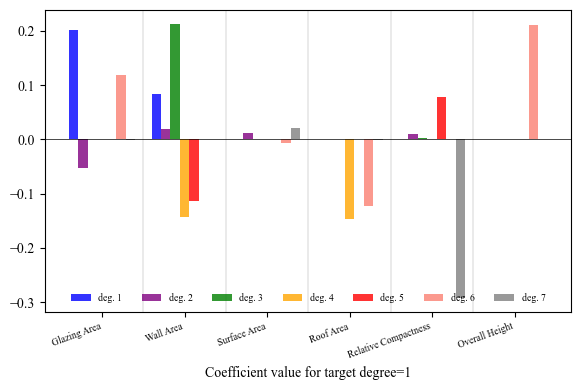

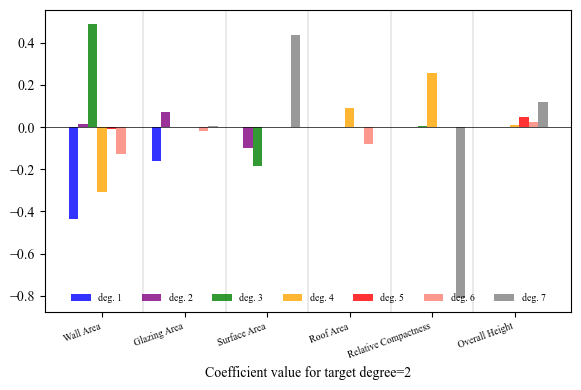

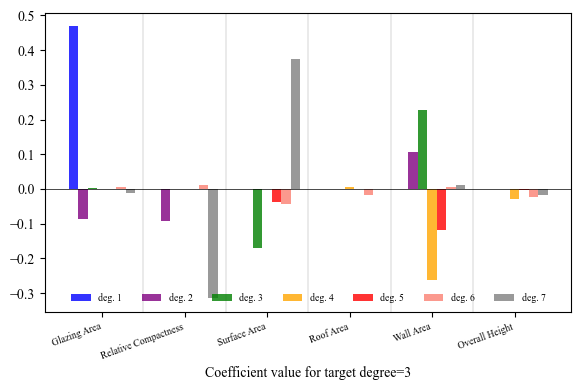

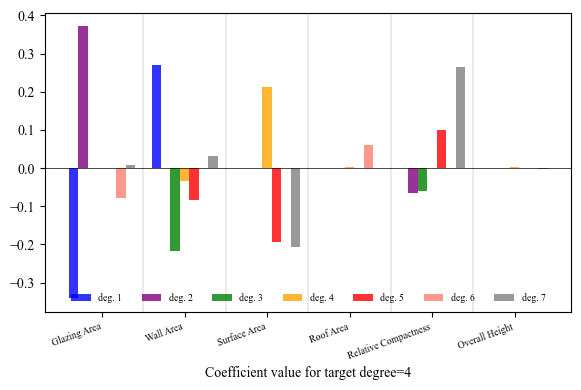

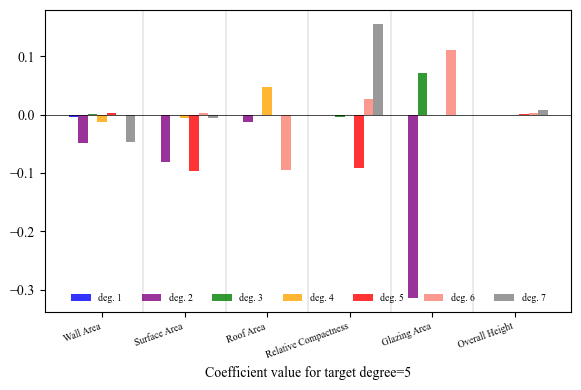

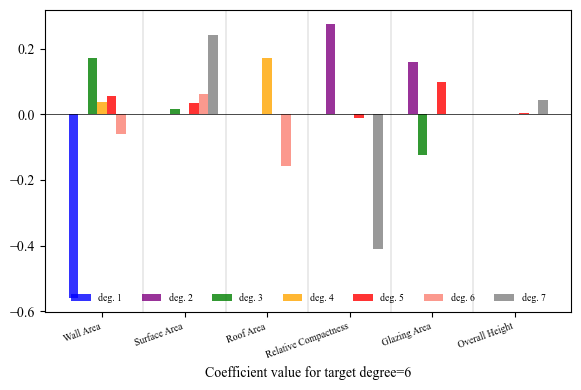

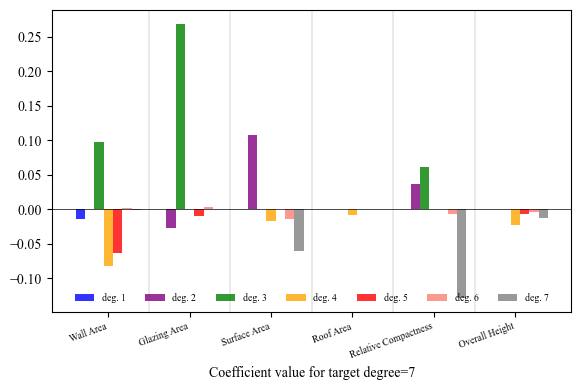

In [67]:
from src.weights import plot_coeffs, coeffs_mean

_, _, coeffs_list = results_six["param-softplus"]
coeffs = coeffs_mean(coeffs_list)

colors = ["blue", "purple", "green", "orange", "red", "salmon", "gray"]
N = 7
for deg in range(1, N+1):
    plot_coeffs(coeffs=coeffs[deg], target_deg=deg, colors=colors)